# Matching-engine benchmarks — the measured difference

Two limit-order-book implementations with identical, differentially-fuzzed
semantics: **MapBook** (`std::map` price levels, `std::list` FIFO queues — the
readable reference and correctness oracle) and **FastBook** (contiguous price
ladder, object pool, intrusive doubly-linked FIFO queues). This notebook reads
`results/benchmarks.csv` — produced by `lob_bench` on the machine documented
below — and turns it into the plots and tables the README quotes.

**Methodology, before any numbers:** single thread pinned to one core; a full
warmup replay excluded from every statistic; throughput measured with one clock
around the whole replay (no per-op timing distortion); latency measured with
TSC reads around every operation (~5–10ns rdtsc-pair cost *included*; Windows
`steady_clock` at 100ns granularity would quantise the percentiles, which is
why TSC); three repetitions per configuration, aggregated by **median** with
min–max shown; identical op streams for both engines. Hardware: AMD Ryzen 7
7730U (laptop, Windows 11, desktop apps running) — a consumer machine, not an
isolated rig, and the tail numbers say so honestly.

In [1]:
%matplotlib inline
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ASSETS = Path("..") / "assets"
ASSETS.mkdir(exist_ok=True)
plt.rcParams["figure.dpi"] = 110

df = pd.read_csv("../results/benchmarks.csv")
df["flow_kind"] = df.flow.str.replace(r"-seed\d+", "", regex=True)

agg = df.groupby(["impl", "flow_kind"]).agg(
    runs=("throughput_mops", "size"),
    tput_med=("throughput_mops", "median"),
    tput_min=("throughput_mops", "min"),
    tput_max=("throughput_mops", "max"),
    p50=("p50_ns", "median"), p90=("p90_ns", "median"),
    p99=("p99_ns", "median"), p999=("p999_ns", "median"),
    max_ns=("max_ns", "median"),
)
agg.round(1)

runs  tput_med  tput_min  tput_max    p50    p90     p99  \
impl     flow_kind                                                             
FastBook lobster       3      14.1       5.0      15.6   30.0  120.0   330.0   
         synthetic     9      11.9       9.4      13.6   30.0  150.0   460.0   
MapBook  lobster       3       6.8       4.8       7.3  110.0  190.0   360.0   
         synthetic     9       5.5       4.6       6.3  100.0  350.0  1072.0   

                      p999     max_ns  
impl     flow_kind                     
FastBook lobster     510.0   910759.0  
         synthetic  1252.0  1633711.0  
MapBook  lobster     881.0   721139.0  
         synthetic  3887.0  2314644.0

## Throughput

Median of the repetitions, with min–max whiskers. The synthetic flow is one
million operations per run (55/25/10/10 submit/cancel/market/reduce around a
random-walking mid); the LOBSTER flow replays the full AMZN 2012-06-21 sample
day — 261k operations dominated by submissions and cancellations, as real
feeds are.

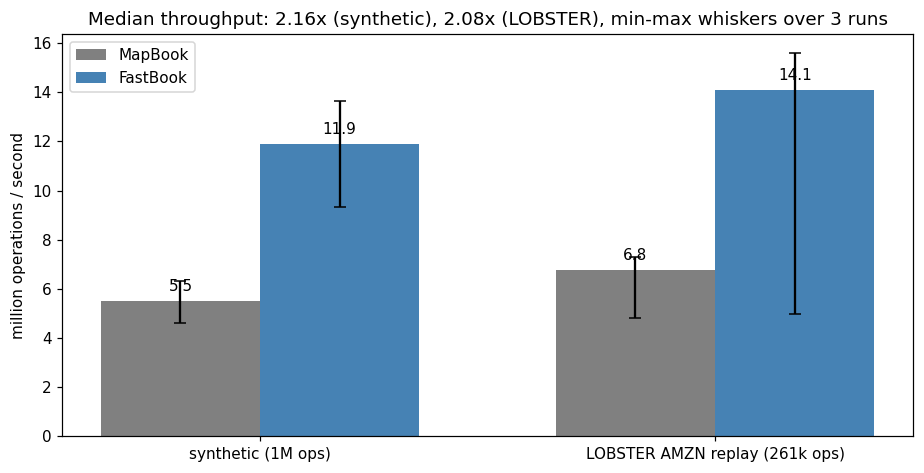

In [2]:
flows = ["synthetic", "lobster"]
impls = ["MapBook", "FastBook"]
colors = {"MapBook": "gray", "FastBook": "steelblue"}

fig, ax = plt.subplots(figsize=(8.5, 4.4))
width = 0.35
x = np.arange(len(flows))
for k, impl in enumerate(impls):
    med = [agg.loc[(impl, f), "tput_med"] for f in flows]
    lo = [med[i] - agg.loc[(impl, f), "tput_min"] for i, f in enumerate(flows)]
    hi = [agg.loc[(impl, f), "tput_max"] - med[i] for i, f in enumerate(flows)]
    bars = ax.bar(x + (k - 0.5) * width, med, width, yerr=[lo, hi], capsize=4,
                  label=impl, color=colors[impl])
    for bar, value in zip(bars, med):
        ax.text(bar.get_x() + bar.get_width() / 2, value + 0.4, f"{value:.1f}",
                ha="center", fontsize=10)
ax.set_xticks(x, ["synthetic (1M ops)", "LOBSTER AMZN replay (261k ops)"])
ax.set_ylabel("million operations / second")
speed_syn = agg.loc[("FastBook", "synthetic"), "tput_med"] / agg.loc[("MapBook", "synthetic"), "tput_med"]
speed_lob = agg.loc[("FastBook", "lobster"), "tput_med"] / agg.loc[("MapBook", "lobster"), "tput_med"]
ax.set_title(f"Median throughput: {speed_syn:.2f}x (synthetic), {speed_lob:.2f}x (LOBSTER), "
             "min-max whiskers over 3 runs")
ax.legend()
fig.tight_layout()
fig.savefig(ASSETS / "throughput.png", bbox_inches="tight")
plt.show()

## Latency percentiles — where the two designs actually differ

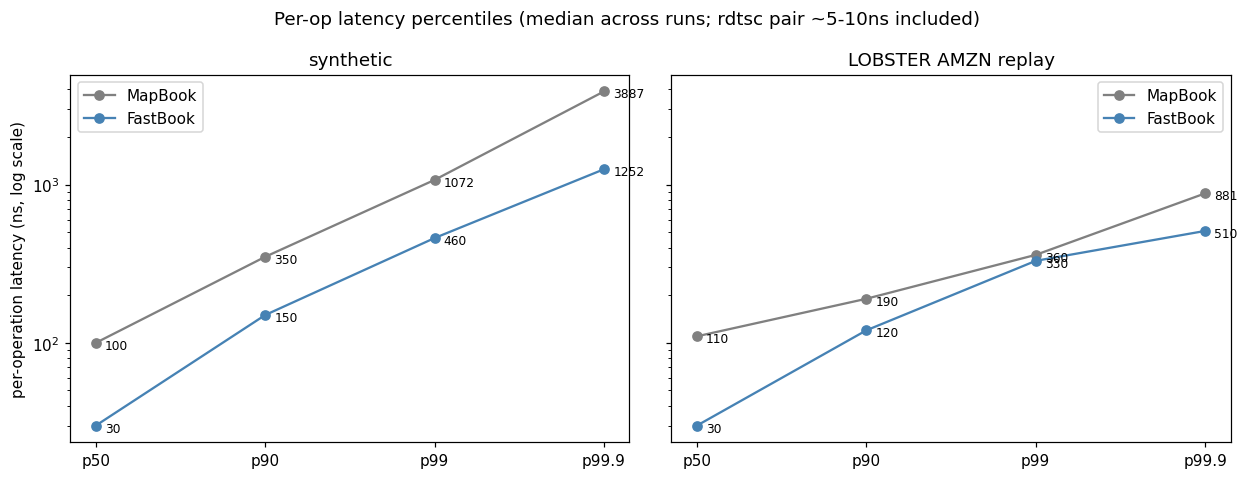

In [3]:
percentiles = ["p50", "p90", "p99", "p999"]
labels = ["p50", "p90", "p99", "p99.9"]

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.4), sharey=True)
for ax, flow in zip(axes, flows):
    for impl in impls:
        values = [agg.loc[(impl, flow), p] for p in percentiles]
        ax.plot(labels, values, marker="o", label=impl, color=colors[impl])
        for lx, v in zip(labels, values):
            ax.annotate(f"{v:.0f}", (lx, v), textcoords="offset points",
                        xytext=(6, -4), fontsize=8)
    ax.set_yscale("log")
    ax.set_title("synthetic" if flow == "synthetic" else "LOBSTER AMZN replay")
    ax.legend()
axes[0].set_ylabel("per-operation latency (ns, log scale)")
fig.suptitle("Per-op latency percentiles (median across runs; rdtsc pair ~5-10ns included)")
fig.tight_layout()
fig.savefig(ASSETS / "latency.png", bbox_inches="tight")
plt.show()

## The optimization receipts: v1 → v2

The first benchmarked version (preserved in `results/benchmarks_v1_baseline.csv`
and in the git history) measured two specific weaknesses, and version 2 fixed
exactly those two things — nothing else changed, so the deltas are attributable:

1. **The sparse-ladder tail.** v1's p99/p99.9 on the LOBSTER replay were
   *worse* than MapBook's: AMZN ticks in $0.0001 on a ~$224 stock, so occupied
   levels sit hundreds of empty ticks apart, and the best-level rescan walked
   them one by one. Fix: an **occupancy bitmap** — one bit per price level,
   scanned 64 ticks per `countr_zero`/`countl_zero` instruction.
2. **The shared hash-map chokepoint.** The id→slot index was a
   `std::unordered_map`, touched by every submit, fill, and cancel — per-node
   allocation and bucket pointer-chasing, exactly the costs the rest of the
   design eliminates. Fix: **`lob::IdMap`** — open addressing, linear probing,
   Fibonacci hashing, and backward-shift deletion (tombstone-free, so lookups
   never degrade under the relentless churn of an order book). It earns trust
   the same way the engines do: a 200k-op randomized differential test against
   `std::unordered_map`.

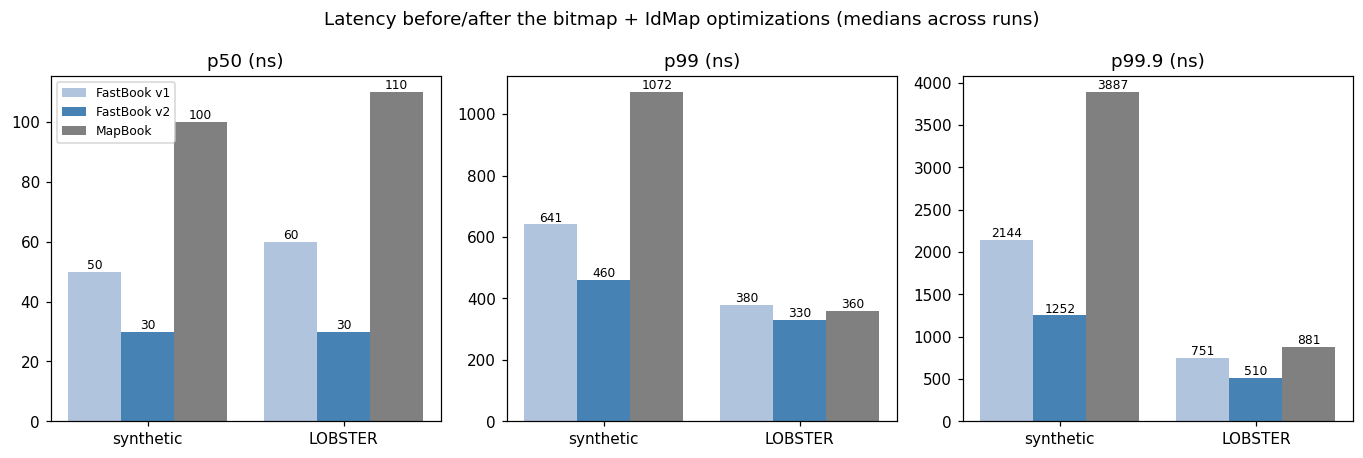

FastBook LOBSTER: v1 -> v2
throughput_mops     11.0
p50_ns              60.0
p99_ns             380.0
p999_ns            751.0
throughput_mops     14.0
p50_ns              30.0
p99_ns             330.0
p999_ns            510.0


In [4]:
v1 = pd.read_csv("../results/benchmarks_v1_baseline.csv")
v1["flow_kind"] = v1.flow.str.replace(r"-seed\d+", "", regex=True)
fast_v1 = v1[v1.impl == "FastBook"].groupby("flow_kind")[
    ["throughput_mops", "p50_ns", "p99_ns", "p999_ns"]].median()
fast_v2 = df[df.impl == "FastBook"].groupby("flow_kind")[
    ["throughput_mops", "p50_ns", "p99_ns", "p999_ns"]].median()
map_v2 = df[df.impl == "MapBook"].groupby("flow_kind")[
    ["throughput_mops", "p50_ns", "p99_ns", "p999_ns"]].median()

fig, axes = plt.subplots(1, 3, figsize=(12.5, 4.2))
metrics = [("p50_ns", "p50 (ns)"), ("p99_ns", "p99 (ns)"), ("p999_ns", "p99.9 (ns)")]
x = np.arange(len(flows))
width = 0.27
for ax, (col, label) in zip(axes, metrics):
    for k, (frame, name, color) in enumerate([
            (fast_v1, "FastBook v1", "lightsteelblue"),
            (fast_v2, "FastBook v2", "steelblue"),
            (map_v2, "MapBook", "gray")]):
        vals = [frame.loc[f, col] for f in flows]
        bars = ax.bar(x + (k - 1) * width, vals, width, label=name, color=color)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width() / 2, v, f"{v:.0f}",
                    ha="center", va="bottom", fontsize=8)
    ax.set_xticks(x, ["synthetic", "LOBSTER"])
    ax.set_title(label)
axes[0].legend(fontsize=8)
fig.suptitle("Latency before/after the bitmap + IdMap optimizations "
             "(medians across runs)")
fig.tight_layout()
fig.savefig(ASSETS / "optimization.png", bbox_inches="tight")
plt.show()

print("FastBook LOBSTER: v1 -> v2")
print(fast_v1.loc["lobster"].round(0).to_string())
print(fast_v2.loc["lobster"].round(0).to_string())

## Reading the numbers honestly

**Where FastBook v2 wins.** Median latency is now ~30ns against MapBook's
~100–110ns (3.3–3.7x) on both flows, throughput is ~2.1x, and — the part v1
could not claim — the tail is better everywhere: on the LOBSTER replay p99
went 380 → 330ns (MapBook: ~360ns) and p99.9 went 751 → 510ns (MapBook:
~881ns). The regression that v1 reported honestly is fixed, with the receipt
attached above.

**What stayed honest.** Synthetic *throughput* medians barely moved between
v1 and v2 (12.2 → 11.9 Mops/s) even though every latency percentile improved
substantially — whole-replay wall-clock on a desktop laptop carries OS noise
that medians over three runs cannot fully remove, while the latency
percentiles rest on a million samples each and are the more reliable
measurement. Rare max-latency spikes in the 0.5–10ms range remain on both
engines: page faults and preemption. An isolated-core Linux rig with locked
pages is the right environment for citing absolute tail numbers; this repo's
claim is the *relative* comparison under identical conditions.

**And the number that matters most is not on a chart:** every operation stream
used here produces identical fills, identical return values, and identical
book snapshots on both engines — enforced continuously by the differential
fuzz suite (25 seeds x 20k ops plus a 200k-op session per CI run, under
ASan/UBSan), which is also what made it safe to swap the guts of FastBook and
know within seconds that nothing broke. Fast numbers from a wrong book are
worthless; correctness is the benchmark's precondition, not its afterthought.